# InSb and In$_x$Ga$_{1-x}$Sb dots: band alignment and confined levels

Four dot/matrix combinations, plus **InAs in GaAs** as a type-I reference that behaves the way a
quantum dot is supposed to:

| dot | matrix | why |
|---|---|---|
| InSb | InAs | the most strained case, and the one benchmarked against Pryor & Pistol |
| InSb | InAs$_{1-y}$Sb$_y$ | the same dot on a metamorphic buffer — **strain is the variable** |
| In$_x$Ga$_{1-x}$Sb | InAs | composition as the knob instead |
| In$_x$Ga$_{1-x}$Sb | InAs$_{1-y}$Sb$_y$ | both knobs at once |
| InAs | GaAs | the control: an ordinary type-I dot |

An InAs$_{1-y}$Sb$_y$ matrix is not a cosmetic change. Misfit is set by lattice constants alone,
so alloying the *matrix* toward InSb relieves it directly: at $y = 0.3$ the InSb dot goes from
$-6.5\%$ to $-4.5\%$ and the In$_{0.5}$Ga$_{0.5}$Sb dot from $-3.6\%$ to $-1.6\%$. Everything
downstream — the strain-shifted edges, the well depths, the levels — moves with it.

## Read this before reading any number below

**The machinery is validated; the parameter set is benchmarked once, on one quantity.**

- The elasticity solver passes five tests including an exact closed form at machine precision,
  and reproduces Pryor's own method.
- The parameters reproduce Pryor & Pistol's **analytic pseudomorphic well** to 0 meV on both band
  edges — a closed form, so nothing numerical flatters it.
- The same parameters miss their **dot** by about $-29$ meV once the periodic box is converged,
  and that residual is unexplained. It is not the parameter set, which the well exonerates. It
  lives in the shape or the 3D strain field.

**What is genuinely uncertain here**, and it matters for everything below:

- `e14` and $\varepsilon_r$ are not from the Vurgaftman review's own tables. The piezoelectric
  potential is built entirely from them, and `e14`'s sign disagrees with Pryor 1998. Every
  figure below is run with piezoelectricity **on**; re-run with `USE_PIEZO = False` to see what
  it is worth.
- Alloy electron masses are inconsistent in the source by 9–16% — bowing $m_e$ directly and
  bowing the Kane ingredients disagree. Since the binding threshold goes as $1/m$, that is a
  9–16% uncertainty on every critical size for an alloy.
- First-order piezoelectricity only, and linear elasticity at up to 6.5% misfit.

Nothing here is a substitute for `materials.audit()`, which prints the provenance of every value.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import materials as mt
import heterostructure as hs
import ingasb_dot as ig

mt.set_temperature(0.0)          # 0 K: what the rest of the parameter set is. Try 77 or 300.
print(f"T = {mt.TEMPERATURE:g} K")

T = 0 K


## Parameters

Everything below is driven from this cell. `RADIUS` is the island's base radius and `ASPECT` is
$h/d$, so the island is `2*RADIUS` across — Pryor & Pistol's spherical cap at $h/d = 1/4$.

### `PAD` is a real physics knob, and it is set here for speed

`elasticity_fd` is periodic, so a tight box lets the island feel its own images. The dot gap moves
**55 meV** between `pad = 5` and `pad = 30` nm and converges only past ~25 nm — see
`scripts/insb_box_convergence.py`, which is the study; this notebook is not.

`PAD = 8` is chosen so the notebook runs in minutes, and the binding constraint is
`electron_states`, **not** the strain solve. The strain solve is a preconditioned CG that
converges in 8 iterations at any of these sizes. The single-band eigensolve is over the *whole
box*, so its cost scales with the padding rather than with the island:

| grid | sites | strain solve | `electron_states` |
|---|---|---|---|
| h = 0.75, pad = 8 | 65k | 2 s | 21 s |
| **h = 0.6, pad = 8** | **126k** | **5 s** | **46 s** |
| h = 0.6, pad = 10 | 183k | 11 s | 118 s |
| h = 0.5, pad = 8 | 218k | 13 s | 166 s |

Roughly $n^{1.7}$. At `pad = 12, h = 0.5` (950k sites) that cell needs about three hours for five
systems, which is how this setting got chosen — the first version of this notebook timed out
there.

**What it costs you:** absolute band edges here are biased high by roughly 20–25 meV against a
converged box, near-uniformly across systems. Differences *between* systems, the alignment types,
the well locations and the binding verdicts are far less sensitive. Quote absolute edges from
`scripts/insb_box_convergence.py`, not from here.

In [2]:
RADIUS, ASPECT = 10.0, 0.25      # spherical cap, 20 nm across, h/d = 1/4
H = 0.6                          # grid spacing, nm
PAD = 8.0                        # matrix padding, nm -- a SPEED choice with a cost; see above
USE_PIEZO = True

X_INGASB = 0.50                  # In fraction of the In(x)Ga(1-x)Sb dot
Y_INASSB = 0.30                  # Sb fraction of the InAs(1-y)Sb(y) matrix

SHAPE = hs.spherical_lens(RADIUS, 2 * RADIUS * ASPECT)

SYSTEMS = [
    ('InSb',                 'InAs',              'InSb / InAs'),
    ('InSb',                 ('InAsSb', Y_INASSB), 'InSb / InAsSb'),
    (('InGaSb', X_INGASB),   'InAs',              'InGaSb / InAs'),
    (('InGaSb', X_INGASB),   ('InAsSb', Y_INASSB), 'InGaSb / InAsSb'),
    ('InAs',                 'GaAs',              'InAs / GaAs  (type-I reference)'),
]
print(SHAPE['label'], f"  volume {SHAPE['volume']:.0f} nm^3")

spherical lens r = 10 nm, h = 5 nm (h/d = 0.25)   volume 851 nm^3


---
## 1. Where the bands sit before any strain

The unstrained lineup is the starting point, not the answer — strain moves these edges by several
hundred meV and can change the alignment type outright. But it says what kind of system each pair
*wants* to be.

Positive $E_v(\text{dot}) - E_c(\text{matrix})$ is **broken gap**: the dot's valence edge lies
above the matrix's conduction edge, so electrons and holes separate across the interface before
strain does anything at all.

In [3]:
mt.alignment_table('InGaSb', compositions=(0.0, 0.25, 0.5, 0.75, 1.0), matrix='InAs')
print()
mt.alignment_table('InAsSb', compositions=(0.0, 0.25, 0.5, 0.75, 1.0), matrix='InAs')

energy zero = unstrained InAs valence edge; InAs: E_v = 0.000, E_c = 0.417 eV   (T = 0 K)
unstrained alignment
    x           name   misfit      Eg      E_v      E_c   E_v(dot)-E_c(mat)  alignment
 0.00           GaSb   -0.52%   0.812    0.560    1.372              +0.143  broken gap (III)
 0.25 In0.25Ga0.75Sb   -2.08%   0.590    0.568    1.157              +0.151  broken gap (III)
 0.50 In0.50Ga0.50Sb   -3.59%   0.420    0.575    0.995              +0.158  broken gap (III)
 0.75 In0.75Ga0.25Sb   -5.05%   0.301    0.583    0.884              +0.166  broken gap (III)
 1.00           InSb   -6.48%   0.235    0.590    0.825              +0.173  broken gap (III)

positive last column = broken gap: the dot's valence edge lies above the InAs
conduction edge, so electrons stay in the matrix and holes in the dot.

energy zero = unstrained InAs valence edge; InAs: E_v = 0.000, E_c = 0.417 eV   (T = 0 K)
unstrained alignment
    x           name   misfit      Eg      E_v      E_c   E_v(dot)-E_c

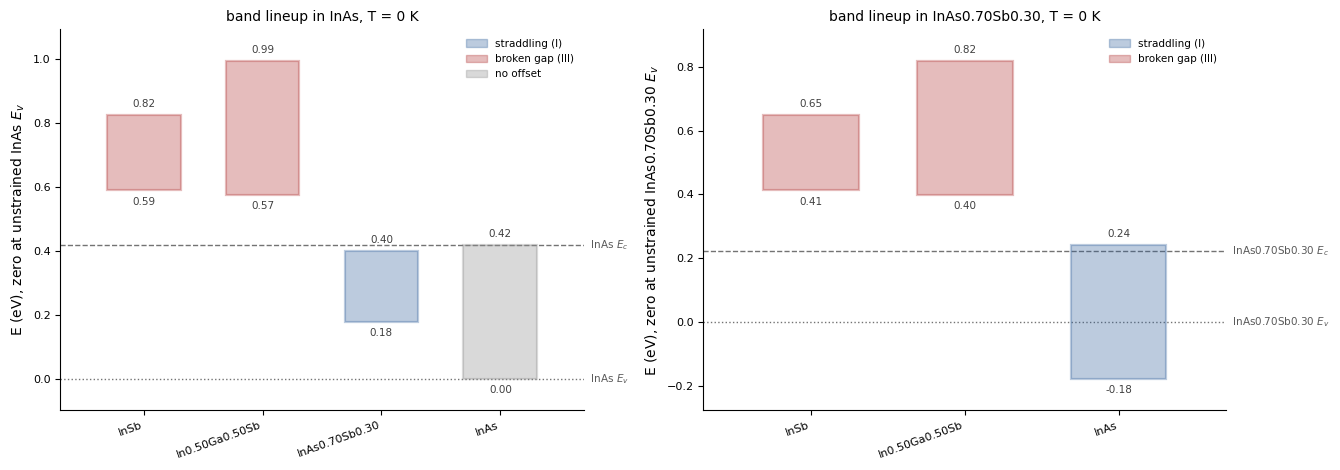

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
mt.plot_alignment(['InSb', ('InGaSb', X_INGASB), ('InAsSb', Y_INASSB), 'InAs'],
                  matrix='InAs', ax=axes[0])
mt.plot_alignment(['InSb', ('InGaSb', X_INGASB), 'InAs'],
                  matrix=('InAsSb', Y_INASSB), ax=axes[1])
fig.tight_layout()

---
## 2. The strain solve

`elasticity_fd` solves inhomogeneous continuum elasticity with position-dependent $C_{ijkl}$ on a
periodic cell — Pryor's own real-space method, not a homogeneous Fourier solver. That choice
matters here: the electron well in these systems lives in the **matrix**, where a homogeneous
solver gets the stiffness contrast wrong.

This is the slow cell, roughly half a minute per system.

In [5]:
envs = {}
rows = []
for dot, matrix, label in SYSTEMS:
    env = hs.build(SHAPE, dot, matrix=matrix, h=H, pad=PAD,
                   use_piezo=USE_PIEZO, verbose=False)
    envs[label] = env
    g = env['strain'].at(env['mask'])
    a = env['alignment']
    rows.append((label, env['dot']['name'], env['matrix']['name'], env['eps_star'],
                 g['exx'] + g['eyy'] + g['ezz'], a['type'], a['e_well'], a['h_well']))

print(f"{'system':<34}{'misfit':>9}{'<Tr eps>':>11}{'alignment':>19}"
      f"{'e-well':>9}{'h-well':>9}")
for label, d, m, eps, tr, typ, ew, hw in rows:
    print(f"{label:<34}{eps*100:>8.2f}%{tr:>11.5f}{typ:>19}"
          f"{ew*1e3:>+8.0f}m{hw*1e3:>+8.0f}m")
print("\ne-well / h-well are the hydrostatic-only single-particle offsets: positive means the")
print("dot confines that carrier. They ignore the shear, which is why section 4 recomputes the")
print("valence edge exactly.")

system                               misfit   <Tr eps>          alignment   e-well   h-well
InSb / InAs                          -6.48%   -0.08244   broken gap (III)    -980m    +560m
InSb / InAsSb                        -4.53%   -0.05641   broken gap (III)    -818m    +393m
InGaSb / InAs                        -3.59%   -0.04551   broken gap (III)    -906m    +549m
InGaSb / InAsSb                      -1.59%   -0.01967   broken gap (III)    -738m    +387m
InAs / GaAs  (type-I reference)      -6.75%   -0.09520     straddling (I)    +408m    +115m

e-well / h-well are the hydrostatic-only single-particle offsets: positive means the
dot confines that carrier. They ignore the shear, which is why section 4 recomputes the
valence edge exactly.


**Alloying the matrix relieves the strain, and it does it monotonically.** Compare the two
InSb rows and the two InGaSb rows: the misfit drops, $\langle \mathrm{Tr}\,\varepsilon \rangle$
follows it, and both well depths shrink. That is the whole reason for a metamorphic buffer, and it
is the cleanest knob in this system because it acts through the lattice constant alone.

---
## 3. Where the bands sit *after* strain

The same diagram as section 1, now with each dot's mean hydrostatic strain applied. Compression
pushes $E_c$ up and $E_v$ down — the gap opens by $|a_{gap}\,\mathrm{Tr}\,\varepsilon|$, and with
$a_c + a_v \approx -7$ eV and $\mathrm{Tr}\,\varepsilon \approx -0.08$ that is more than half an
electron-volt.

Only the hydrostatic part is in this picture. The shear splits heavy and light hole by hundreds of
meV more, and section 4 does it properly.

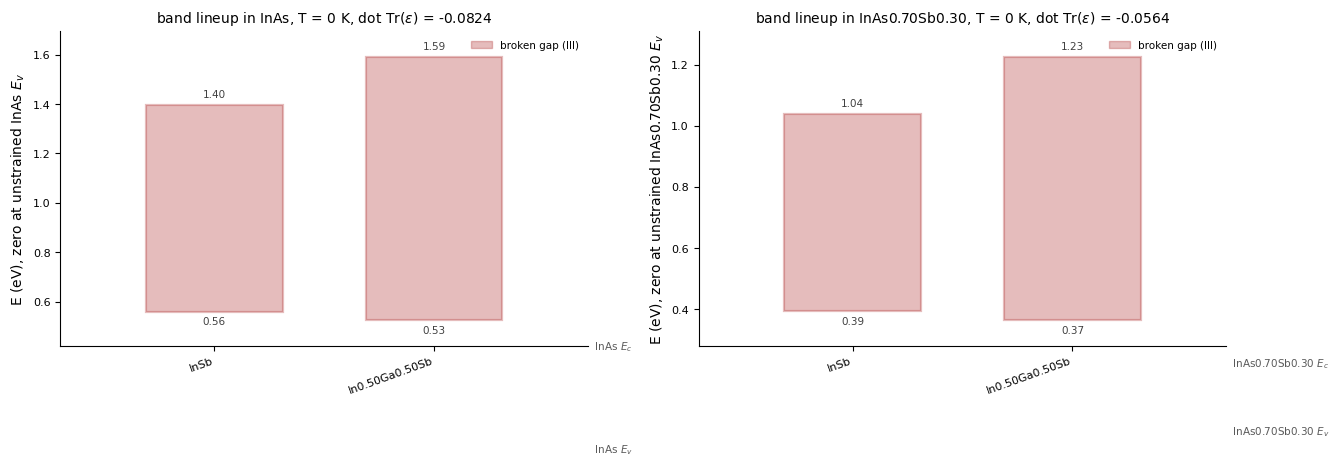

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for ax, (matrix, dots) in zip(axes, [
        ('InAs', ['InSb', ('InGaSb', X_INGASB)]),
        (('InAsSb', Y_INASSB), ['InSb', ('InGaSb', X_INGASB)])]):
    # One representative Tr(eps): the InSb dot's. The alloy dot's differs, so this diagram is
    # indicative for it -- the per-system numbers in section 2 are the exact ones.
    key = 'InSb / InAs' if matrix == 'InAs' else 'InSb / InAsSb'
    g = envs[key]['strain'].at(envs[key]['mask'])
    mt.plot_alignment(dots, matrix=matrix, trace_strain=g['exx'] + g['eyy'] + g['ezz'], ax=ax)
fig.tight_layout()

---
## 4. The wells, in space

`valence_edge` is the exact $k = 0$ top of the local valence band — the largest eigenvalue of the
$6\times6$ valence block of the strain Hamiltonian, so the full Bir–Pikus shear is in it. In a dot
strained by several percent the shear is not a correction: it splits heavy and light hole by
hundreds of meV and it is what sets the hole well depth.

Dashed and dotted grey lines are the unstrained **matrix** edges. Those are the thresholds that
define binding: a carrier is confined only where the local edge lies on the confining side of
them.

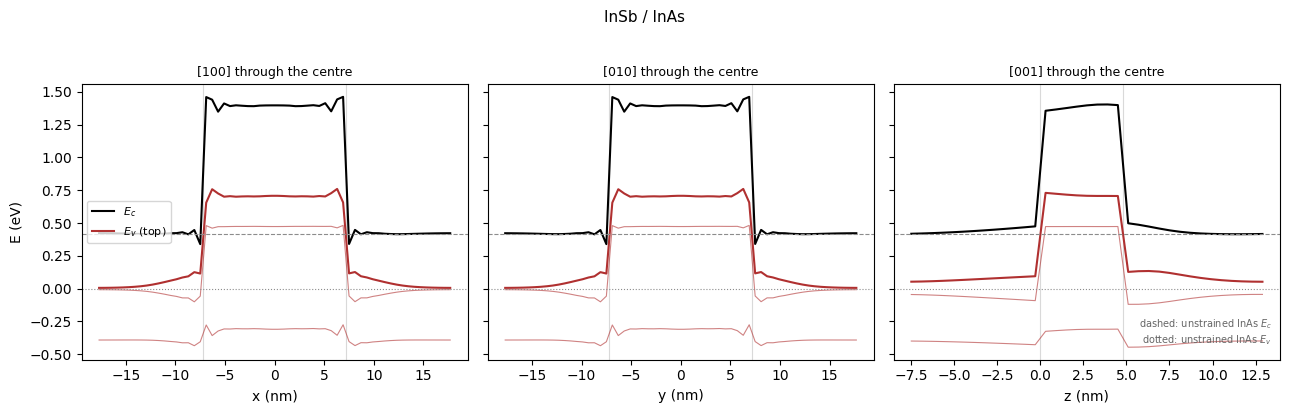

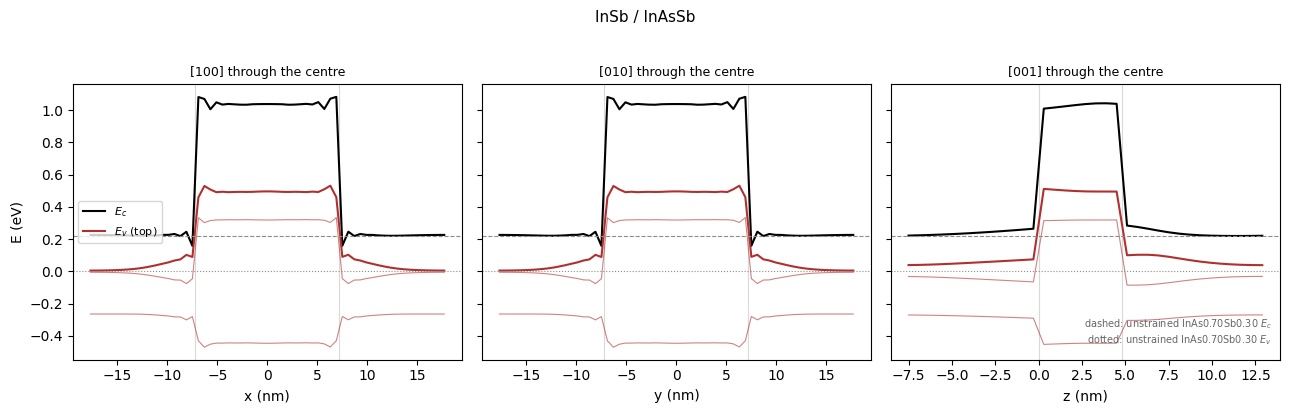

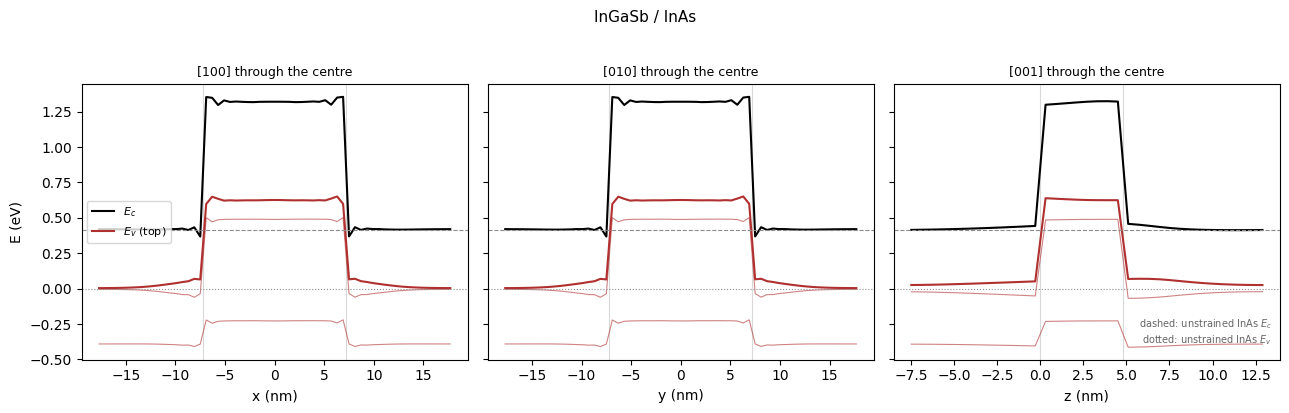

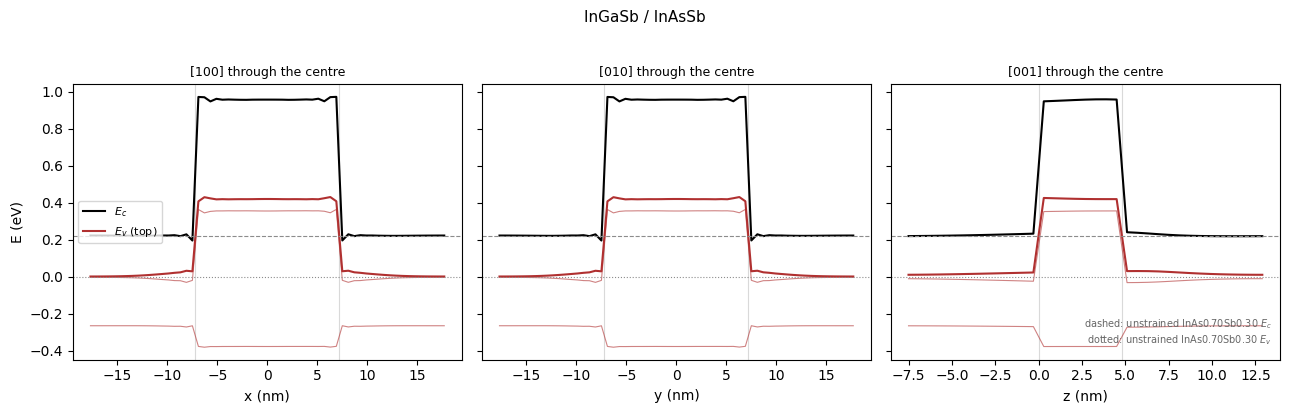

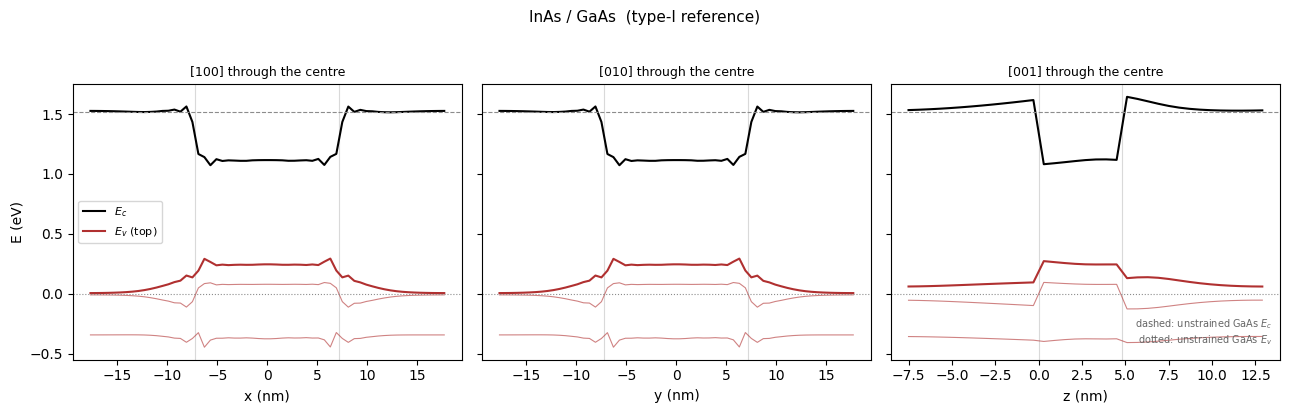

In [7]:
for label, env in envs.items():
    fig = hs.plot_bands(env)
    fig.suptitle(label, fontsize=11, y=1.02)
    plt.show()

Read the antimonide panels against the InAs/GaAs one. In the reference system the
conduction edge **drops** inside the island — an ordinary electron well. In the antimonide
systems it rises steeply inside the dot and dips *below* the far-field line only in a thin shell
**outside** it, in the matrix put into tension by the island's compression. That shell is the only
thing that could hold an electron, and section 5 measures whether it can.

---
## 5. Can it hold anything, and how big would it have to be?

`confinement` makes no assumption about which side of the interface a carrier sits on. For each
carrier it builds a *binding depth field* — how far the local edge lies on the confining side of
the far-field matrix value — and the well is wherever that is positive. The `in dot` column
reports which region that turned out to be, rather than assuming it from the alignment type.

The criterion is $V_0 R^2 > \pi^2\hbar^2/8m^*$ on a sphere of the same volume. **Failing it is
decisive** — a real well binds no better than that sphere, and a thin shell binds far worse.
Passing is only suggestive, so section 6 solves for the states.

Rows marked *reaches the box wall* are discarded, not reported: such a region is bounded by the
padding rather than by the island, and its volume grows without limit as `PAD` grows.

In [8]:
for label, env in envs.items():
    print('=' * 100)
    hs.confinement(env)
    print()

spherical lens r = 10 nm, h = 5 nm (h/d = 0.25)   InSb in InAs
  alignment broken gap (III)   (unstrained overlap E_v(dot)-E_c(matrix) = +143 meV)

  ELECTRON
    m* = 0.0260 m0  ->  needs V0 R^2 > 3.61 eV nm^2
      below     volume   equiv R  mean depth    V0R^2   in dot  verdict
         0m      803.5      5.77       19.2m     0.64       0%  REACHES THE BOX WALL -- discarded
        10m      305.9      4.18       44.5m     0.78       0%  too weak
        25m      143.0      3.24       78.0m     0.82       0%  too weak
        50m       99.4      2.87       97.9m     0.81       0%  too weak
       100m       35.9      2.05      126.0m     0.53       0%  too weak
    would need the island 2.10x larger: 42.0 nm against 20.0 nm now [best contour: 25 meV]

  HOLE
    m* = 0.4604 m0  ->  needs V0 R^2 > 0.20 eV nm^2
      below     volume   equiv R  mean depth    V0R^2   in dot  verdict
         0m    25843.5     18.34       44.7m    15.03       3%  REACHES THE BOX WALL -- discarded
      

spherical lens r = 10 nm, h = 5 nm (h/d = 0.25)   InSb in InAs0.70Sb0.30
  alignment broken gap (III)   (unstrained overlap E_v(dot)-E_c(matrix) = +171 meV)

  ELECTRON
    m* = 0.0128 m0  ->  needs V0 R^2 > 7.35 eV nm^2
      below     volume   equiv R  mean depth    V0R^2   in dot  verdict
         0m      770.3      5.69       15.5m     0.50       0%  REACHES THE BOX WALL -- discarded
        10m      232.8      3.82       43.4m     0.63       0%  too weak
        25m      115.3      3.02       72.1m     0.66       0%  too weak
        50m       92.9      2.81       80.9m     0.64       0%  too weak
       100m       14.7      1.52      113.6m     0.26       0%  too weak
    would need the island 3.34x larger: 66.9 nm against 20.0 nm now [best contour: 25 meV]

  HOLE
    m* = 0.4347 m0  ->  needs V0 R^2 > 0.22 eV nm^2
      below     volume   equiv R  mean depth    V0R^2   in dot  verdict
         0m    26632.8     18.53       32.4m    11.11       3%  REACHES THE BOX WALL -- discar

spherical lens r = 10 nm, h = 5 nm (h/d = 0.25)   In0.50Ga0.50Sb in InAs
  alignment broken gap (III)   (unstrained overlap E_v(dot)-E_c(matrix) = +132 meV)

  ELECTRON
    m* = 0.0260 m0  ->  needs V0 R^2 > 3.61 eV nm^2
      below     volume   equiv R  mean depth    V0R^2   in dot  verdict
         0m      856.7      5.89       10.1m     0.35       0%  REACHES THE BOX WALL -- discarded
        10m      177.6      3.49       38.8m     0.47       0%  too weak
        25m      107.6      2.95       54.6m     0.47       0%  too weak
        50m       67.0      2.52       63.7m     0.40       0%  too weak
       100m        0.4      0.47      102.3m     0.02       0%  too weak
    would need the island 2.76x larger: 55.2 nm against 20.0 nm now [best contour: 25 meV]

  HOLE
    m* = 0.4608 m0  ->  needs V0 R^2 > 0.20 eV nm^2
      below     volume   equiv R  mean depth    V0R^2   in dot  verdict
         0m    25725.2     18.31       32.3m    10.82       3%  REACHES THE BOX WALL -- discar

spherical lens r = 10 nm, h = 5 nm (h/d = 0.25)   In0.50Ga0.50Sb in InAs0.70Sb0.30
  alignment broken gap (III)   (unstrained overlap E_v(dot)-E_c(matrix) = +165 meV)

  ELECTRON
    m* = 0.0128 m0  ->  needs V0 R^2 > 7.35 eV nm^2
      below     volume   equiv R  mean depth    V0R^2   in dot  verdict
         0m      842.4      5.86        5.1m     0.17       0%  REACHES THE BOX WALL -- discarded
        10m      114.5      3.01       26.7m     0.24       0%  too weak
        25m       70.0      2.56       31.9m     0.21       0%  too weak
        50m        0.4      0.47       51.1m     0.01       0%  too weak
       100m         --
    would need the island 5.51x larger: 110.2 nm against 20.0 nm now [best contour: 10 meV]

  HOLE
    m* = 0.4351 m0  ->  needs V0 R^2 > 0.22 eV nm^2
      below     volume   equiv R  mean depth    V0R^2   in dot  verdict
         0m    26785.3     18.56       18.7m     6.44       3%  REACHES THE BOX WALL -- discarded
        10m     5168.4     10.73   

spherical lens r = 10 nm, h = 5 nm (h/d = 0.25)   InAs in GaAs
  alignment straddling (I)   (unstrained overlap E_v(dot)-E_c(matrix) = -1404 meV)

  ELECTRON
    m* = 0.0540 m0  ->  needs V0 R^2 > 1.74 eV nm^2
      below     volume   equiv R  mean depth    V0R^2   in dot  verdict
         0m     2660.3      8.60      140.9m    10.41      32%  could bind
        10m     1657.6      7.34      223.5m    12.04      51%  could bind
        25m     1080.9      6.37      334.2m    13.55      78%  could bind
        50m      951.3      6.10      375.2m    13.96      88%  could bind
       100m      912.4      6.02      387.9m    14.04      92%  could bind
    clears the threshold at this size (20.0 nm, 2.09x margin) [best contour: 100 meV]

  HOLE
    m* = 0.5474 m0  ->  needs V0 R^2 > 0.17 eV nm^2
      below     volume   equiv R  mean depth    V0R^2   in dot  verdict
         0m    22844.6     17.60       37.1m    11.48       4%  REACHES THE BOX WALL -- discarded
        10m    14134.2     

In [9]:
print(f"{'system':<34}{'e V0R2/thr':>12}{'e core in dot':>15}{'e critical':>12}"
      f"{'h V0R2/thr':>12}{'h core in dot':>15}{'h critical':>12}")
for label, env in envs.items():
    out = []
    for carrier in ('electron', 'hole'):
        crit = hs.critical_size(env, carrier)
        core = hs.well_core(env, carrier)
        ratio = crit['VR2'] / crit['threshold'] if np.isfinite(crit['threshold']) else np.nan
        size = 'binds' if crit['factor'] <= 1.0 else (
            f"{crit['critical']:.0f} nm" if np.isfinite(crit['critical']) else '--')
        out += [f"{ratio:.2f}" if np.isfinite(ratio) else '--',
                f"{core['frac_in_dot']*100:.0f}%", size]
    print(f"{label:<34}{out[0]:>12}{out[1]:>15}{out[2]:>12}"
          f"{out[3]:>12}{out[4]:>15}{out[5]:>12}")
print("\n'critical' is the smallest island of THIS SHAPE that could confine that carrier.")
print("One solve gives it because continuum elasticity has no length scale: at fixed shape the")
print("band edges are size-independent, so V0 is fixed and R scales exactly with island size.")
print("It is good to ~2 significant figures -- box-converged but not resolution-converged.")

system                              e V0R2/thr  e core in dot  e critical  h V0R2/thr  h core in dot  h critical


InSb / InAs                               0.23             0%       42 nm      103.87           100%       binds


InSb / InAsSb                             0.09             0%       67 nm       71.91           100%       binds


InGaSb / InAs                             0.13             0%       55 nm       91.73           100%       binds


InGaSb / InAsSb                           0.03             0%      110 nm       61.37           100%       binds


InAs / GaAs  (type-I reference)           4.36           100%       binds       61.69           100%       binds

'critical' is the smallest island of THIS SHAPE that could confine that carrier.
One solve gives it because continuum elasticity has no length scale: at fixed shape the
band edges are size-independent, so V0 is fixed and R scales exactly with island size.
It is good to ~2 significant figures -- box-converged but not resolution-converged.


---
## 6. Electron levels

Single-band, using the Kane-derived band-edge mass of each material and the strained conduction
edge (including the piezoelectric term) as the potential. A state is bound iff it lies below
$E_c$ of the far-field matrix.

A single band is defensible for the electron in these systems — it sits in the matrix, away from
the strongly mixed valence bands. It is **not** defensible for the hole, which is why section 7
uses eight bands.

**Do not read a binding energy off an unbound level.** A finite box always returns eigenvalues;
if they sit above the barrier they are box states, and their energy is set by `PAD`, not by the
physics. They are shown dotted for exactly that reason.

In [10]:
e_states = {}
for label, env in envs.items():
    e_states[label] = hs.electron_states(env, k=4, verbose=False)
    st = e_states[label]
    print(f"{label:<34} bound: {st['n_bound']}/{len(st['E'])}   "
          + '  '.join(f"{e:.4f}" for e in st['E'])
          + f"   (E_c far = {env['Ec_far']:.3f} eV)")

InSb / InAs                        bound: 0/4   0.5264  0.5398  0.5401  0.5611   (E_c far = 0.417 eV)


InSb / InAsSb                      bound: 0/4   0.4012  0.4350  0.4355  0.4842   (E_c far = 0.222 eV)


InGaSb / InAs                      bound: 0/4   0.5177  0.5317  0.5319  0.5531   (E_c far = 0.417 eV)


InGaSb / InAsSb                    bound: 0/4   0.3892  0.4240  0.4241  0.4735   (E_c far = 0.222 eV)


InAs / GaAs  (type-I reference)    bound: 3/4   1.3391  1.4360  1.4426  1.5323   (E_c far = 1.519 eV)


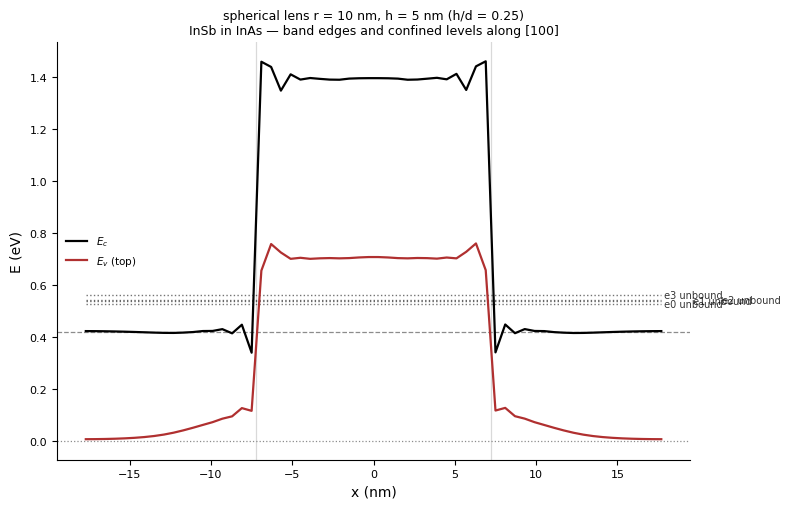

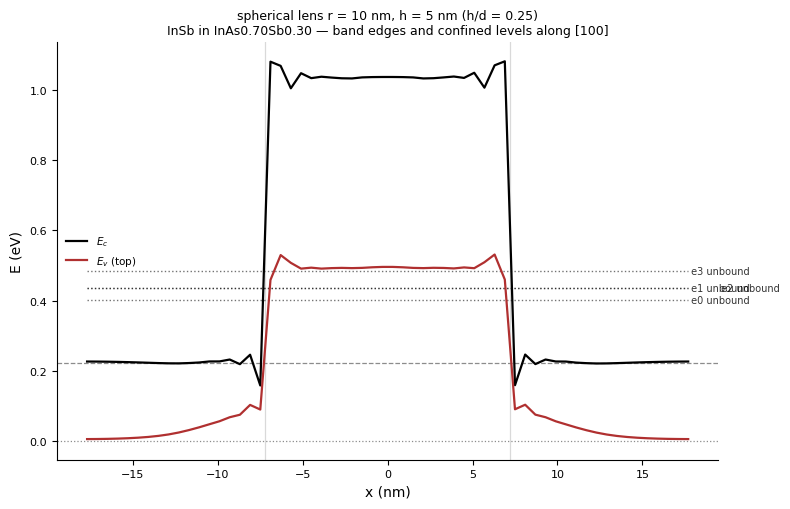

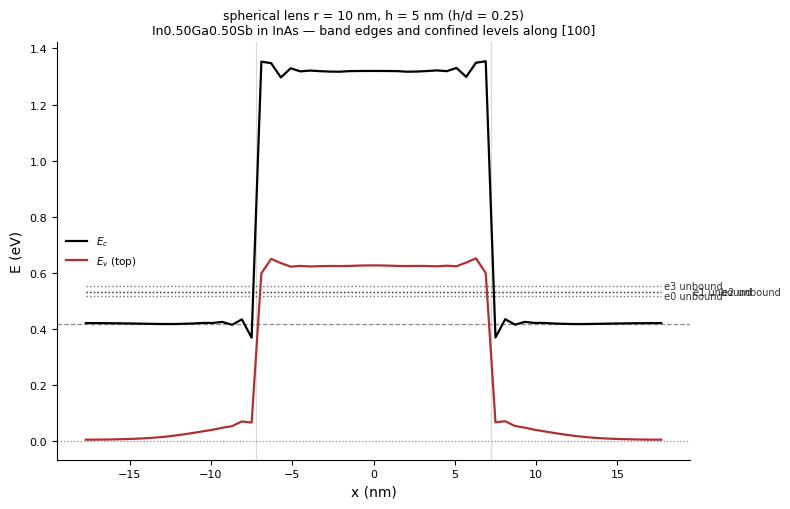

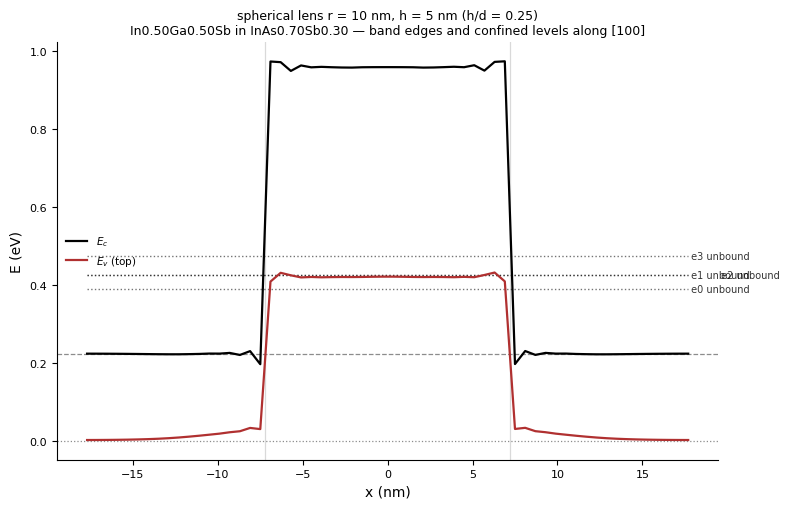

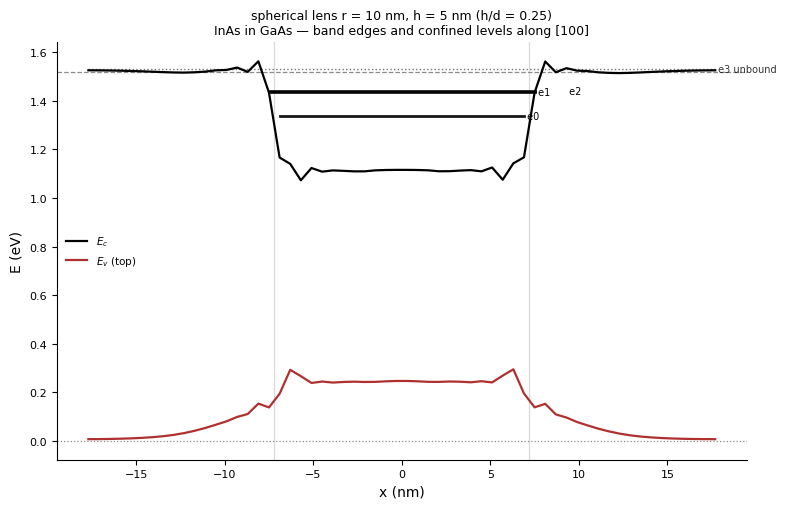

In [11]:
for label, env in envs.items():
    fig = hs.plot_levels(env, electron=e_states[label], cut='x')
    plt.show()

Only the type-I reference binds an electron. In every antimonide system the levels sit
**above** the far-field conduction edge — they are box states, and the honest reading is that the
strain pocket does not confine an electron, which is what section 5 predicted from $V_0R^2$
without solving anything.

That does not mean there is no bound electron. It means there is no *single-particle* well. In a
broken-gap dot the electron is held by Coulomb attraction to the hole, as an exciton, and none of
the machinery here includes that.

---
## 7. The hole

### 7a. The well, which is free

A single band cannot describe the hole in a narrow-gap heavily strained alloy — the valence bands
are strongly mixed and the shear splitting is comparable to the gap — so there is no cheap hole
*level*. But the hole **well** costs nothing beyond the strain solve already done:
`valence_edge` is the exact $k=0$ top of the local valence band, the largest eigenvalue of the
$6\times6$ valence block, with the full Bir–Pikus shear in it.

That depth is the physically meaningful number, and it is what section 5 fed to the binding
criterion.

In [12]:
print(f"{'system':<34}{'E_v in dot':>12}{'far-field':>11}{'depth':>10}"
      f"{'above matrix max':>18}")
for label, env in envs.items():
    w = ig.hole_well(env)
    print(f"{label:<34}{w['v_in']:>12.4f}{w['far']:>11.4f}{w['depth']*1e3:>9.0f}m"
          f"{w['above_matrix']*1e3:>17.0f}m")
print("\nAll in the electron convention: a larger positive depth is a more strongly confined")
print("hole. 'above matrix max' is the margin over the best the matrix offers anywhere, so a")
print("positive value means the hole has nowhere else to go.")

system                              E_v in dot  far-field     depth  above matrix max


InSb / InAs                             0.8429     0.0000      843m              605m


InSb / InAsSb                           0.5875     0.0000      587m              412m


InGaSb / InAs                           0.6975     0.0000      698m              565m


InGaSb / InAsSb                         0.4508     0.0000      451m              391m


InAs / GaAs  (type-I reference)         0.3888     0.0000      389m              117m

All in the electron convention: a larger positive depth is a more strongly confined
hole. 'above matrix max' is the margin over the best the matrix offers anywhere, so a
positive value means the hole has nowhere else to go.


### 7b. Eight-band levels — expensive, and off by default

**This is genuinely costly in this system, and it is worth knowing why before you turn it on.**

`eigensolvers.solve_interior` uses the *folded spectrum* method: it targets states near $\sigma$
by minimising $(A - \sigma)^2$, because a shift-invert factorisation is unaffordable at eight-band
sizes. The price, which its own docstring states, is that squaring the operator **squares the
eigenvalue gaps** — relative separations shrink and LOBPCG converges slowly. In a broken-gap
spectrum that is at its worst: the dot's valence edge lies above the matrix's conduction edge, so
dot-like valence states and matrix-like conduction states are interleaved at the same energy and
$\sigma$ has no clean gap to sit in.

Measured here, on a deliberately coarse 28×28×13 grid — 81,536 unknowns, 1/90th of this
notebook's working grid:

```
E      = [0.7896, 0.7897, 0.7898, 0.7898]      after 505 s
inside = [0.01,   0.01,   0.01,   0.01  ]
```

**It cost eight minutes and it did not find the hole.** Those states are 1% inside the island:
they are matrix states that happened to lie nearest $\sigma$. The residual is small and certifies
they are genuine eigenpairs — of the wrong states. This is not a performance problem that a
bigger machine fixes; it is the σ-placement problem, and it is why a raw `eight_band_states` call
should not be trusted in a broken-gap system.

So it is **off by default**. If you want hole levels, the right tool is not the cell below but
`ingasb_dot.hole_ladder`, which was written for exactly this difficulty: it scans $\sigma$ and
**keeps only what localises**, rather than trusting one target. `ingasb_dot.hole_size_sweep`
checkpoints to JSON so an interrupted sweep resumes. The cell below is left in place because
seeing it return 1%-localised states is the evidence for the paragraph above.

**Whatever you use, read the localisation fraction and not just the energy.** A folded-spectrum
solve returns the eigenvalues nearest $\sigma$, and its residual certifies only that they *are*
eigenpairs — not that they are the ones you wanted. The fraction inside the dot is the only thing
distinguishing a hole state from a matrix electron state at the same energy.

In [13]:
RUN_HOLE_LEVELS = False          # set True and expect to wait; see above
HOLE_SYSTEM = 'InSb / InAs'
HOLE_GRID = dict(h=1.0, pad=4.0)  # a deliberately coarse, dedicated grid

h_states = {}
if RUN_HOLE_LEVELS:
    dot, matrix, _ = next(s for s in SYSTEMS if s[2] == HOLE_SYSTEM)
    # A tight box is defensible for the HOLE specifically -- it is bound by hundreds of meV, so
    # its wavefunction decays within a nm or two. It would not be defensible for the electron,
    # whose states here are barely bound or unbound and would just measure the box.
    env_h = hs.build(SHAPE, dot, matrix=matrix, use_piezo=USE_PIEZO, vol_tol=0.30,
                     verbose=False, **HOLE_GRID)
    print(f"{HOLE_SYSTEM}: {env_h['mask'].size*8:,} unknowns")
    h_states[HOLE_SYSTEM] = hs.eight_band_states(env_h, band='vb', k=4, verbose=True)
    fig = hs.plot_levels(env_h, hole=h_states[HOLE_SYSTEM], cut='x')
    plt.show()
else:
    print("skipped -- set RUN_HOLE_LEVELS = True to solve for hole levels.")
    print("For a converged ladder use ingasb_dot.hole_ladder / hole_size_sweep instead.")

skipped -- set RUN_HOLE_LEVELS = True to solve for hole levels.
For a converged ladder use ingasb_dot.hole_ladder / hole_size_sweep instead.


---
## 8. What this says

1. **Holes are confined in every one of these systems, easily.** The valence well is deep,
   compact, and sits inside the island. Nothing marginal about it.
2. **Electrons are not confined in any of the antimonide systems.** The only electron well is a
   thin tensile shell in the matrix, outside the island, and it falls short of the binding
   threshold by a factor of several. Making the dot bigger would fix it in principle — section 5
   gives the size — but the required islands are far larger than the ones being grown.
3. **The InAsSb buffer relieves strain monotonically** and shrinks both wells with it. It is the
   cleanest knob available, because it acts purely through the lattice constant.
4. **InAs/GaAs behaves completely differently**, as it should: both carriers bound, both inside
   the island, strong overlap. It is in this notebook as the control that shows the antimonide
   result is a property of those materials and not of the machinery.

The practical consequence is that these are **spatially indirect** emitters. Electron–hole overlap
is small, radiative lifetimes are long, and any model that puts both carriers in the dot — which
includes most textbook quantum-dot formulae — does not apply.

### What would change these conclusions

- **Coulomb binding**, which is excluded throughout and is what actually holds the electron.
- **The piezoelectric constants**, whose provenance is weak and whose sign disagrees with Pryor
  1998. Re-run with `USE_PIEZO = False`.
- **The alloy electron mass**, uncertain by 9–16% in the source, which propagates directly into
  every critical size.
- **A converged box.** `PAD = 8` nm here is a speed compromise worth ~20–25 meV on the absolute
  edges; the converged study is `scripts/insb_box_convergence.py`.